# Conclusion of Findings

## Master Thesis: Analyzing Rhetorical Framing in Brexit Debates

This thesis examines rhetorical framing patterns in Brexit-related debates in the UK House of Commons. The analysis combines computational methods with political communication theory to identify and analyze how different frames are used across temporal, party-political, geographical, and demographic dimensions.

The research is based on a comprehensive dataset of parliamentary speeches collected from official UK Parliament records, processed and classified using large language models and machine learning techniques. This conclusion summarizes the key findings from the analysis.

In [37]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", None)

# Locate database
search_roots = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
for base in search_roots:
    candidate = base / "data/thesis_final.duckdb"
    if candidate.exists():
        db_path = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate `thesis_final.duckdb` in the current or any parent directories."
    )

con = duckdb.connect(database=str(db_path), read_only=True)

## Data Overview
Analysis of Brexit-related speeches in the UK House of Commons (2012-2022) shows systematic variation linked to key political developments during the withdrawal process.

## Key Statistics
- **Average annual volume**: 2,917 speech chunks across 288 debates (~10 speeches per debate)

## Volume Trends
- **2012**: 386 speeches (baseline)
- **2019**: 8,573 speeches (peak)
- **2021-2022**: ~1,000 speeches annually (post-Brexit normalization)

## Interpretation
Speech volume peaked during the political gridlock under the May administration (2018-2019) and declined after:
- Formal UK departure: January 31, 2020
- Trade and Cooperation Agreement: December 2020

## Main Finding
**Inverse relationship between speech volume and political progress**: When executive action stalled, parliamentary discourse intensified. The struggle over framing and interpretation of Brexit escalated precisely when concrete political progress was blocked.

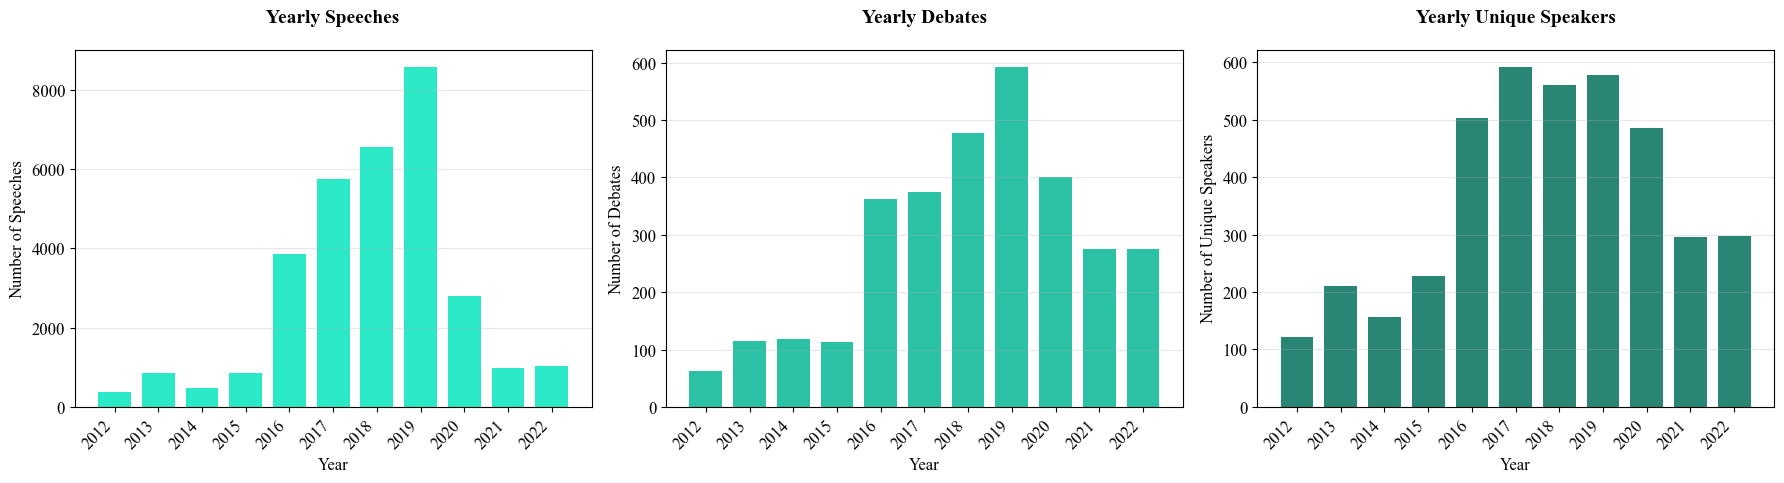

In [38]:
# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

years = yearly_overview["year"].astype(str)
positions = np.arange(len(years))
bar_width = 0.75

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Speeches
axes[0].bar(positions, yearly_overview["speeches"], width=bar_width, color="#06E6BC", alpha=0.85)
axes[0].set_title("Yearly Speeches", fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel("Number of Speeches", fontsize=12)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].tick_params(axis='x', labelsize=12)
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xticks(positions)
axes[0].set_xticklabels(years, rotation=45, ha='right')

# Plot 2: Debates
axes[1].bar(positions, yearly_overview["debates"], width=bar_width, color="#05B696", alpha=0.85)
axes[1].set_title("Yearly Debates", fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel("Number of Debates", fontsize=12)
axes[1].set_xlabel("Year", fontsize=12)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(positions)
axes[1].set_xticklabels(years, rotation=45, ha='right')

# Plot 3: Unique Speakers
axes[2].bar(positions, yearly_overview["unique_speakers"], width=bar_width, color="#03715D", alpha=0.85)
axes[2].set_title("Yearly Unique Speakers", fontsize=14, fontweight='bold', pad=20)
axes[2].set_ylabel("Number of Unique Speakers", fontsize=12)
axes[2].set_xlabel("Year", fontsize=12)
axes[2].tick_params(axis='y', labelsize=12)
axes[2].tick_params(axis='x', labelsize=12)
axes[2].grid(axis="y", alpha=0.3)
axes[2].set_xticks(positions)
axes[2].set_xticklabels(years, rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Temporal Phases of Brexit Discourse

The Brexit discourse can be divided into distinct temporal phases, each characterized by specific political events and rhetorical dynamics:

| Phase | Time frame | Definition |
|-------|------------|------------|
| Pre-Brexit Baseline | January 1, 2012 - January 22, 2013 | This phase serves as a counterfactual baseline, capturing parliamentary debates before Cameron's formal referendum announcement. It provides a control period representing "normal" EU-related discourse prior to Brexit becoming a defining political issue. |
| Pre-Referendum | January 23, 2013 - June 22, 2016 | Beginning with Cameron's Bloomberg speech announcing the referendum and the subsequent campaign period, this phase reflects initial framing contests over sovereignty, economic implications, and European integration. |
| Post-Referendum Shock | June 23, 2016 - March 28, 2017 | Immediately following the referendum result, this phase includes Cameron's resignation and Theresa May's ascension to Prime Minister, characterized by uncertainty and reactive framing around the vote's consequences. |
| Article 50 Phase | March 29, 2017 - November 13, 2018 | Triggered by the invocation of Article 50, this period focuses on formal withdrawal negotiations, with frames likely emphasizing legal, economic, and diplomatic challenges. |
| Parliamentary Deadlock | November 14, 2018 - July 23, 2019 | Marked by repeated meaningful vote defeats in Parliament and her eventual resignation, this phase captures intensified polarization and procedural framing. |
| Johnson Era & Deal | July 24, 2019 - January 30, 2020 | Covering Boris Johnson's premiership, the revision of the Withdrawal Agreement, and his landslide election victory, this phase captures shifts toward decisive, outcome-oriented frames. |
| Transition & Exit | January 31, 2020 - December 31, 2020 | Encompassing the UK's formal exit from the EU and negotiations on future relations during the transition period, this phase examines frames related to adaptation and long-term impacts. |
| Post-Brexit Baseline | January 1, 2021 - December 31, 2022 | This two-year post-implementation phase captures debates during the consolidation of the new UK-EU relationship, providing a comparison endpoint for assessing long-term frame persistence or evolution after institutional uncertainty ends. |


In addition to these phases, a set of 12 critical events was identified as potential "focusing events"

| Event | Date |
|-------|------|
| Cameron's Referendum Announcement | January 23, 2013 |
| Brexit Referendum Itself | June 23, 2016 |
| Cameron's Resignation | June 24, 2016 |
| Triggering of Article 50 | March 29, 2017 |
| May's Deal | January 15, 2019 |
| Votes on May's Deal | November 15, 2018; March 12, 2019; March 29, 2019 |
| Johnson's Appointment as Prime Minister | July 24, 2019 |
| General Election Victory | December 12, 2019 |
| Brexit Day | January 31, 2020 |
| End of Transition Period | December 31, 2020 |


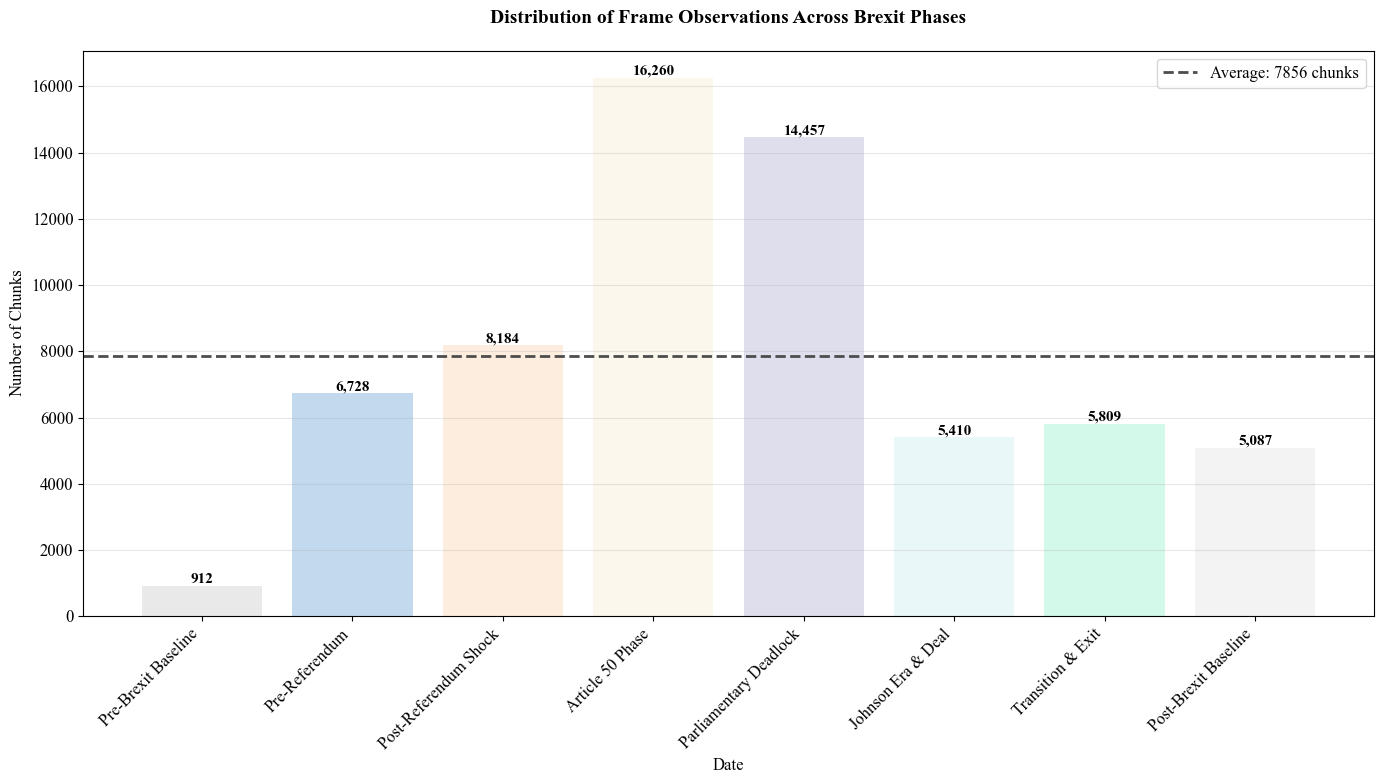

In [39]:
# Import necessary libraries
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from pathlib import Path

# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Database connection - use same approach as first cell
search_roots = [Path.cwd().resolve()] + list(Path.cwd().resolve().parents)
for base in search_roots:
    candidate = base / "data/thesis_final.duckdb"
    if candidate.exists():
        db_path = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate `thesis_final.duckdb` in the current or any parent directories."
    )

conn = duckdb.connect(database=str(db_path), read_only=True)

# Definition of Brexit phases (mit den gleichen Farben wie PHASE_COLORS)
BREXIT_PHASES = {
    'Pre-Brexit Baseline': {
        'start': date(2012, 1, 1),
        'end': date(2013, 1, 22),
        'color': '#E6E6E6'
    },
    'Pre-Referendum': {
        'start': date(2013, 1, 23),
        'end': date(2016, 6, 22),
        'color': '#B8D3EB'
    },
    'Post-Referendum Shock': {
        'start': date(2016, 6, 23),
        'end': date(2017, 3, 28),
        'color': '#FDEAD9'
    },
    'Article 50 Phase': {
        'start': date(2017, 3, 29),
        'end': date(2018, 11, 13),
        'color': '#FBF6E9'
    },
    'Parliamentary Deadlock': {
        'start': date(2018, 11, 14),
        'end': date(2019, 7, 23),
        'color': '#D9D9EA'
    },
    'Johnson Era & Deal': {
        'start': date(2019, 7, 24),
        'end': date(2020, 1, 30),
        'color': '#E7F6F8'
    },
    'Transition & Exit': {
        'start': date(2020, 1, 31),
        'end': date(2020, 12, 31),
        'color': '#CCF8E7'
    },
    'Post-Brexit Baseline': {
        'start': date(2021, 1, 1),
        'end': date(2022, 12, 31),
        'color': '#F2F2F2'
    }
}

# Load chunks data
query = """
SELECT 
    c.chunk_id,
    c.debate_id,
    c.speech_id,
    c.frame_label as frame,
    d.date,
    d.major_heading_text
FROM chunks c
JOIN debates d ON c.debate_id = d.debate_id
WHERE c.frame_label IS NOT NULL
ORDER BY d.date
"""

df_chunks = conn.execute(query).df()
df_chunks['date'] = pd.to_datetime(df_chunks['date'])

# Assign each chunk to a Brexit phase
def assign_phase(chunk_date):
    for phase, info in BREXIT_PHASES.items():
        if info['start'] <= chunk_date.date() <= info['end']:
            return phase
    return None

df_chunks['phase'] = df_chunks['date'].apply(assign_phase)

# Count chunks per phase
phase_counts = df_chunks.groupby('phase').size().reset_index(name='count')

# Calculate average (mean) chunks per phase
average_chunks = phase_counts['count'].mean()

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Define phase order
phase_order = list(BREXIT_PHASES.keys())
phase_counts['phase'] = pd.Categorical(phase_counts['phase'], categories=phase_order, ordered=True)
phase_counts = phase_counts.sort_values('phase')

# Get colors for each phase
colors = [BREXIT_PHASES[phase]['color'] for phase in phase_counts['phase']]

# Create bar chart (ohne edgecolor)
bars = ax.bar(range(len(phase_counts)), phase_counts['count'], color=colors, alpha=0.85)

# Add average line
ax.axhline(y=average_chunks, color='#4D4D4D', linestyle='--', linewidth=2, 
           label=f'Average: {average_chunks:.0f} chunks')

# Customize plot
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Chunks', fontsize=12)
ax.set_title('Distribution of Frame Observations Across Brexit Phases', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(phase_counts)))
ax.set_xticklabels(phase_counts['phase'], rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=12, loc='upper right')

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, phase_counts['count'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()
# Close database connection
conn.close()

The graph shows how intensely Brexit was debated in Parliament over time, with two major peaks during the 2017-2019 negotiations and parliamentary deadlock period. The Article 50 Phase and Parliamentary Deadlock had the highest activity with over 14,000-16,000 frame observations each, reflecting the technical complexity of withdrawal negotiations and the constitutional crisis when May's deal failed to pass. Before the referendum, there was moderate debate setting up the terms of discussion, while the periods before and after Brexit showed much lower activity. The post-referendum shock period had intermediate levels of debate as MPs reacted to the unexpected result. Once Johnson broke the deadlock through his electoral victory, debate volumes dropped significantly during the deal finalization and transition phases. This pattern follows typical policy discourse cycles where major events trigger intense debate that then subsides once institutional solutions emerge and attention shifts to implementation rather than fundamental questions.